In [1]:
# Turn on RAPIDS. Must run before importing pandas
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the cleaned csv file
from google.colab import files
files.upload()
df = pd.read_csv('airbnb_cleaned.csv')

Saving airbnb_cleaned.csv to airbnb_cleaned.csv


In [3]:
print(df.shape)
print(df.isna().sum().sum())

(101845, 23)
0


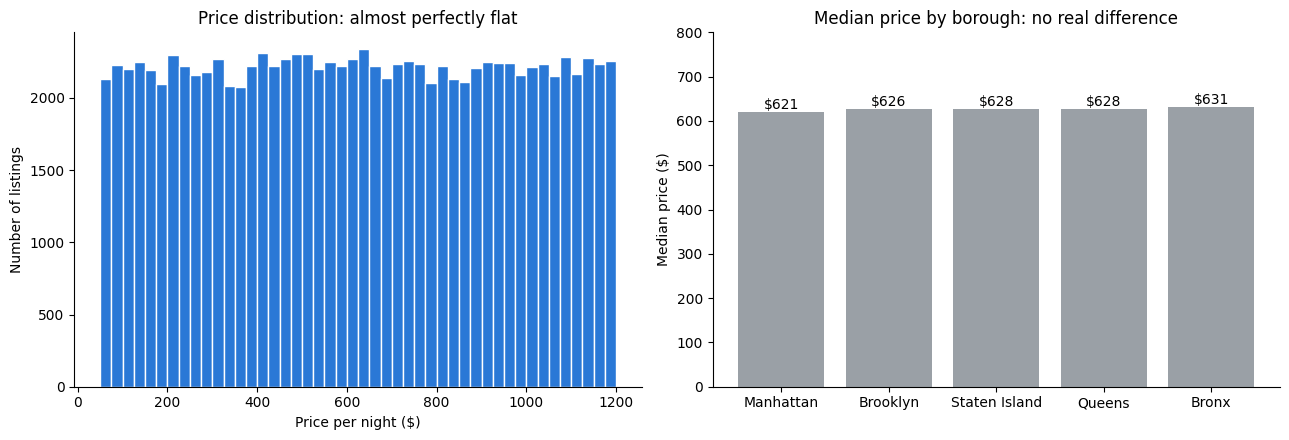

In [4]:
# Lets start with EDA
# first, is price worth predicting? Why is price not our target feature?
# Insight for the slide: Price is uniformly distributed and doesn't vary by location,
# so it's unsuitable as a target. We use reviews per month (demand) instead.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: how prices are spread
axes[0].hist(df['PRICE'], bins=46, color='#2a78d6', edgecolor='white')
axes[0].set_title('Price distribution: almost perfectly flat')
axes[0].set_xlabel('Price per night ($)')
axes[0].set_ylabel('Number of listings')

# Right: median price in each borough
med = df.groupby('NEIGHBOURHOOD_GROUP')['PRICE'].median().sort_values()
bars = axes[1].bar(med.index, med.values, color='#9aa0a6')
axes[1].bar_label(bars, fmt='$%.0f')
axes[1].set_title('Median price by borough: no real difference')
axes[1].set_ylabel('Median price ($)')
axes[1].set_ylim(0, 800)

for a in axes:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_price.png', dpi=150)
plt.show()

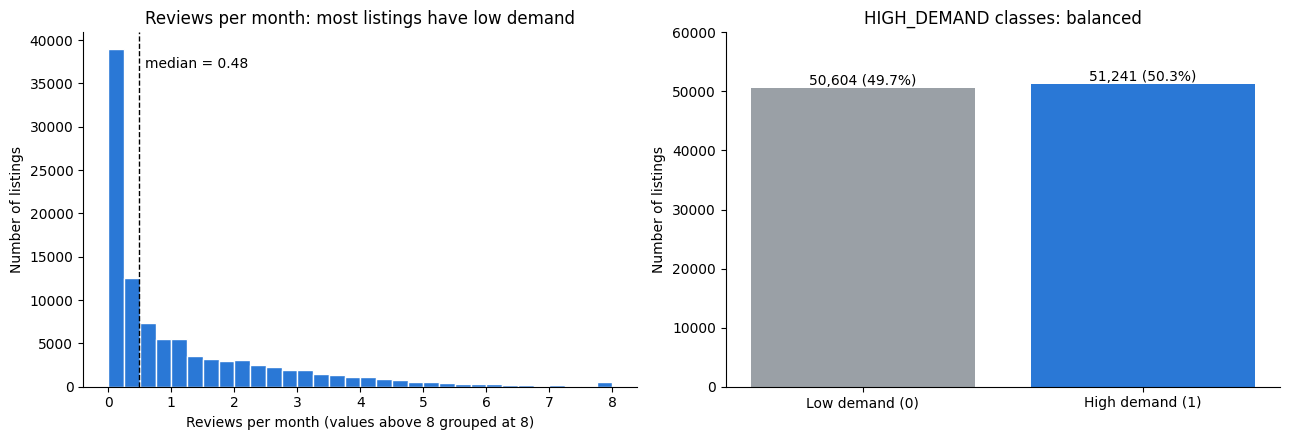

In [5]:
# What does demand look like?
# Since price is not a major distinguisher, we check what moves the demand of a listing.

# Demand is heavily right-skewed: most listings get less than one review a month, while a small group gets many.
# That's typical of real marketplace data, unlike price. Splitting at the median gives two almost equal classes.
# If a listing's reviews per month is at or above the median (0.48), it's high demand (1). Otherwise, it's low demand (0).

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of the target
median_rpm = df['REVIEWS_PER_MONTH'].median()
axes[0].hist(df['REVIEWS_PER_MONTH'].clip(upper=8), bins=32, color='#2a78d6', edgecolor='white')
axes[0].axvline(median_rpm, color='black', linestyle='--', linewidth=1)
axes[0].text(median_rpm + 0.1, axes[0].get_ylim()[1] * 0.9, f'median = {median_rpm:.2f}')
axes[0].set_title('Reviews per month: most listings have low demand')
axes[0].set_xlabel('Reviews per month (values above 8 grouped at 8)')
axes[0].set_ylabel('Number of listings')

# Right: balance of the ML target
counts = df['HIGH_DEMAND'].value_counts().sort_index()
bars = axes[1].bar(['Low demand (0)', 'High demand (1)'], counts.values, color=['#9aa0a6', '#2a78d6'])
axes[1].bar_label(bars, labels=[f'{v:,} ({v/len(df):.1%})' for v in counts.values])
axes[1].set_title('HIGH_DEMAND classes: balanced')
axes[1].set_ylabel('Number of listings')
axes[1].set_ylim(0, 60000)

for a in axes:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_target.png', dpi=150)
plt.show()

                     listings  median_rpm  pct_high
NEIGHBOURHOOD_GROUP                                
Manhattan               43485        0.37  0.454226
Brooklyn                41562        0.49  0.505221
Queens                  13157        0.91  0.612146
Bronx                    2695        1.00  0.657514
Staten Island             946        1.00  0.702960


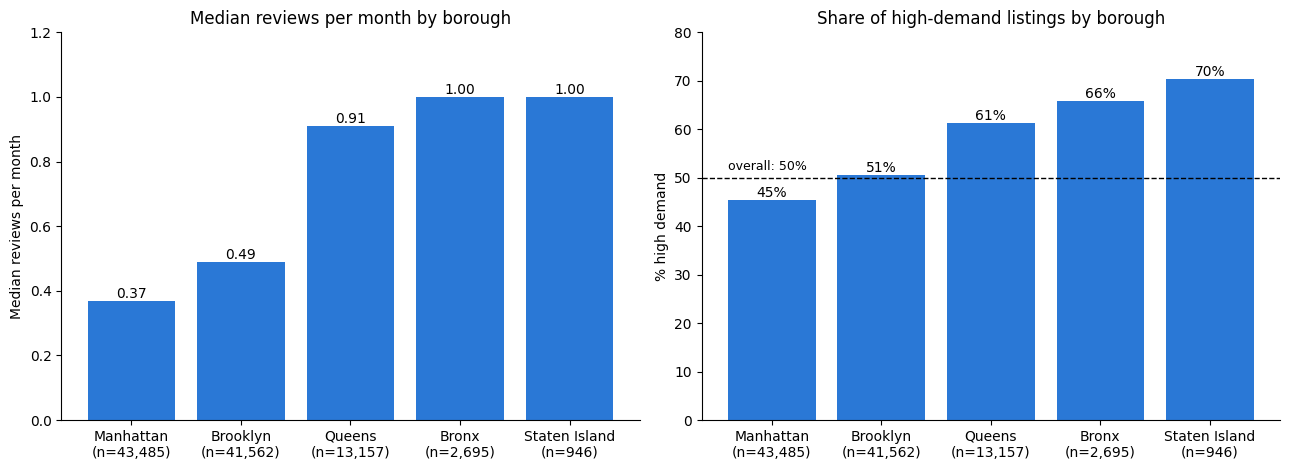

In [6]:
# Next, lets see if demands differ by boroughs.
# Unlike price, demand clearly differs by borough.
# A typical Manhattan listing gets 0.37 reviews a month, while one in the Bronx or Staten Island gets 1.0, almost three times as much.
# The boroughs with the fewest listings have the highest demand per listing."

# Summarise demand per borough
g = (df.groupby('NEIGHBOURHOOD_GROUP')
       .agg(listings=('ID', 'count'),
            median_rpm=('REVIEWS_PER_MONTH', 'median'),
            pct_high=('HIGH_DEMAND', 'mean'))
       .sort_values('median_rpm'))
print(g)

labels = [f'{b}\n(n={n:,})' for b, n in zip(g.index, g['listings'])]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: typical demand per listing
b1 = axes[0].bar(labels, g['median_rpm'], color='#2a78d6')
axes[0].bar_label(b1, fmt='%.2f')
axes[0].set_title('Median reviews per month by borough')
axes[0].set_ylabel('Median reviews per month')
axes[0].set_ylim(0, 1.2)

# Right: share of high-demand listings
b2 = axes[1].bar(labels, g['pct_high'] * 100, color='#2a78d6')
axes[1].bar_label(b2, fmt='%.0f%%')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1)
axes[1].text(-0.4, 51.5, 'overall: 50%', fontsize=9)
axes[1].set_title('Share of high-demand listings by borough')
axes[1].set_ylabel('% high demand')
axes[1].set_ylim(0, 80)

for a in axes:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_borough.png', dpi=150)
plt.show()

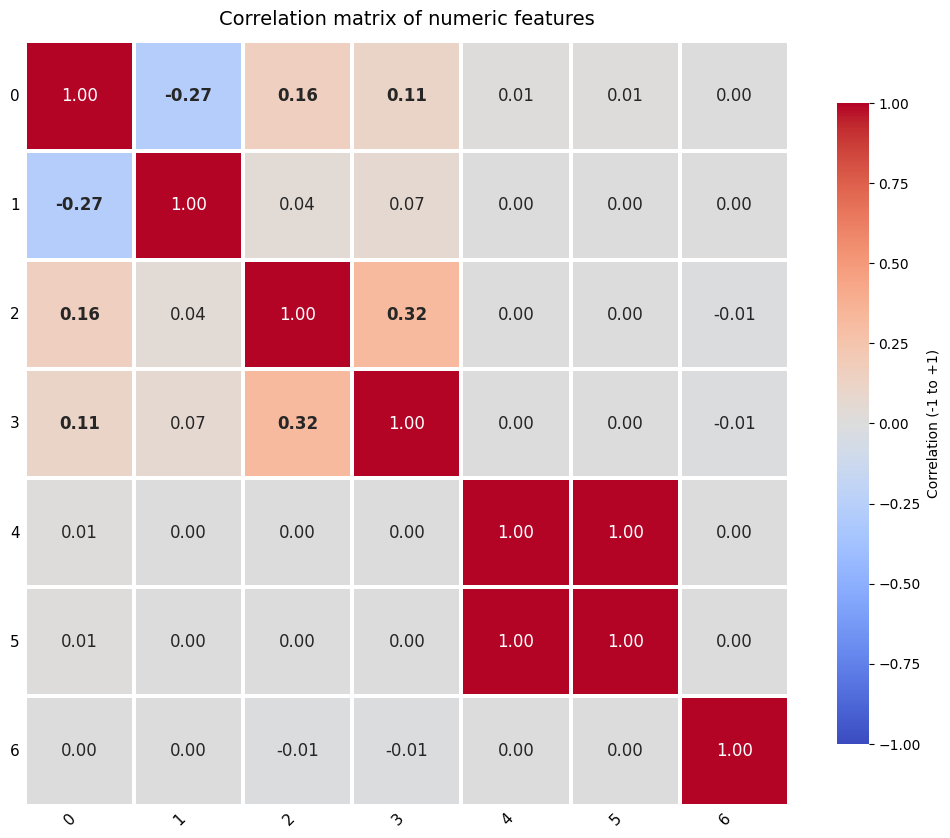

In [14]:
import seaborn as sns

cols = {
    'REVIEWS_PER_MONTH': 'Reviews/month (TARGET)',
    'MINIMUM_NIGHTS': 'Minimum nights',
    'AVAILABILITY_365': 'Availability',
    'CALCULATED_HOST_LISTINGS_COUNT': 'Host listings',
    'PRICE': 'Price',
    'SERVICE_FEE': 'Service fee',
    'CONSTRUCTION_YEAR': 'Construction year'
}
corr = (df[list(cols)].corr(method='spearman').round(2) + 0.0).rename(index=cols, columns=cols)
corr = corr.to_pandas() if hasattr(corr, 'to_pandas') else corr   # safety for RAPIDS

plt.figure(figsize=(10, 8.5))
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
                 square=True, linewidths=1.5, linecolor='white',
                 annot_kws={'size': 12},
                 cbar_kws={'shrink': 0.8, 'label': 'Correlation (-1 to +1)'})

# Bold meaningful values (0.10 or more, excluding the 1.00 diagonal)
for t in ax.texts:
    v = abs(float(t.get_text()))
    if 0.1 <= v < 1:
        t.set_fontweight('bold')

ax.tick_params(axis='both', labelsize=11, length=0)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
ax.set_title('Correlation matrix of numeric features', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150)
plt.show()